#Anti-Jewish Hate Crime Prediction - Complete Analysis

##Libraries & Data Loading

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

df = pd.read_csv('NYPD_Hate_Crimes.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns\n")

print(df.info())

print(df.head())

print("Column Names:")
print(df.columns.tolist())

Dataset loaded: 3872 rows, 14 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3872 entries, 0 to 3871
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Full Complaint ID              3872 non-null   int64  
 1   Complaint Year Number          3872 non-null   int64  
 2   Month Number                   3872 non-null   int64  
 3   Record Create Date             3872 non-null   object 
 4   Complaint Precinct Code        3872 non-null   int64  
 5   Patrol Borough Name            3872 non-null   object 
 6   County                         3872 non-null   object 
 7   Law Code Category Description  3872 non-null   object 
 8   Offense Description            3872 non-null   object 
 9   PD Code Description            3872 non-null   object 
 10  Bias Motive Description        3872 non-null   object 
 11  Offense Category               3872 non-null   object 
 12  Arrest Da

##Target Variable Creation

Anti-Jewish (1): 1817 (46.9%)
Other Biases (0): 2055 (53.1%)


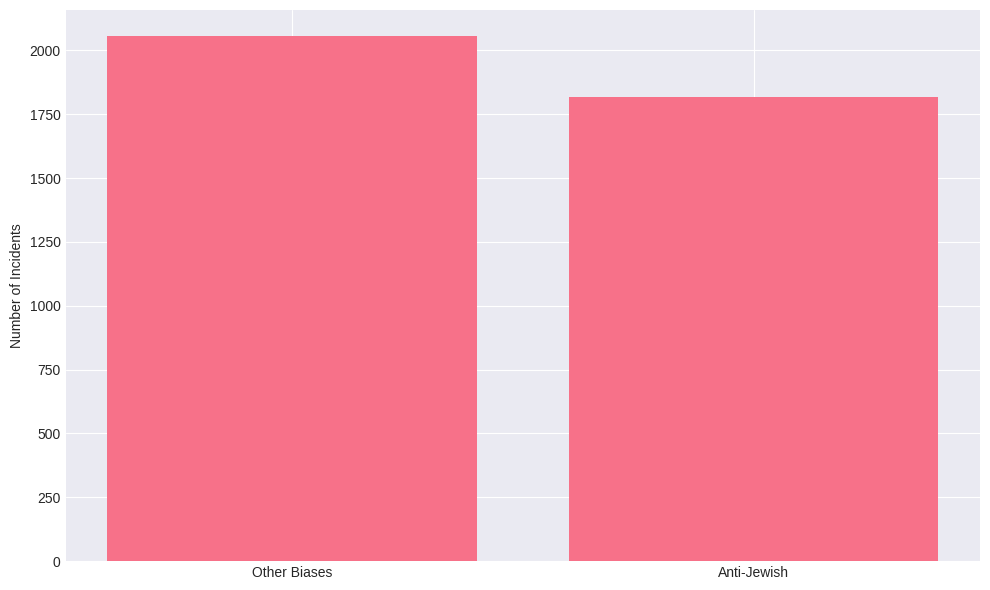

In [92]:
# Binary target: Anti-Jewish = 1, Other = 0
df['target'] = (df['Bias Motive Description'] == 'ANTI-JEWISH').astype(int)
# Distribution check

target_dist = df['target'].value_counts()

print("Anti-Jewish (1):", target_dist.get(1, 0),
      f"({target_dist.get(1, 0)/len(df)*100:.1f}%)")

print("Other Biases (0):", target_dist.get(0, 0),
      f"({target_dist.get(0, 0)/len(df)*100:.1f}%)")

plt.figure(figsize=(10, 6))
plt.bar(['Other Biases', 'Anti-Jewish'],
        [target_dist.get(0, 0), target_dist.get(1, 0)])
plt.ylabel('Number of Incidents')
plt.tight_layout()
plt.show()

#Feature Selection & Missing Value Handling

In [93]:
features = [
    'Complaint Year Number',
    'Month Number',
    'Complaint Precinct Code',
    'Patrol Borough Name',
    'County',
    'Law Code Category Description',
    'Offense Description',
    'PD Code Description',
    'Offense Category'
]

X = df[features].copy()
y = df['target']

# Fill missing values
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].fillna('Unknown')
    else:
        X[col] = X[col].fillna(X[col].median())


#Encoding Categorical Features

In [94]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le


#Data Splitting

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (3097, 9) Test shape: (775, 9)


#Feature Scaling

In [96]:
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])


#Model Selection & vTraining

In [97]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)
    print(name, "trained successfully")


Logistic Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully


#Model Evaluation

In [98]:
results = {}
roc_data = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
    else:
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    results[name] = {'Accuracy': accuracy, 'Precision': precision,
                     'Recall': recall, 'F1-Score': f1, 'AUC-ROC': auc}

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_data[name] = (fpr, tpr, auc)

    print(f"\n{name} Metrics:")
    print("Accuracy:", round(accuracy,3))
    print("Precision:", round(precision,3))
    print("Recall:", round(recall,3))
    print("F1-Score:", round(f1,3))
    print("AUC-ROC:", round(auc,3))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



Logistic Regression Metrics:
Accuracy: 0.694
Precision: 0.687
Recall: 0.64
F1-Score: 0.663
AUC-ROC: 0.751
Confusion Matrix:
 [[305 106]
 [131 233]]

Decision Tree Metrics:
Accuracy: 0.941
Precision: 0.892
Recall: 0.995
F1-Score: 0.94
AUC-ROC: 0.973
Confusion Matrix:
 [[367  44]
 [  2 362]]

Random Forest Metrics:
Accuracy: 0.948
Precision: 0.926
Recall: 0.967
F1-Score: 0.946
AUC-ROC: 0.978
Confusion Matrix:
 [[383  28]
 [ 12 352]]


#Model Comparison & Visualization

In [99]:
results_df = pd.DataFrame(results).T
results_df.round(3)


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Logistic Regression,0.694,0.687,0.640,0.663,0.751
Decision Tree,0.941,0.892,0.995,0.940,0.973
Random Forest,0.948,0.926,0.967,0.946,0.978


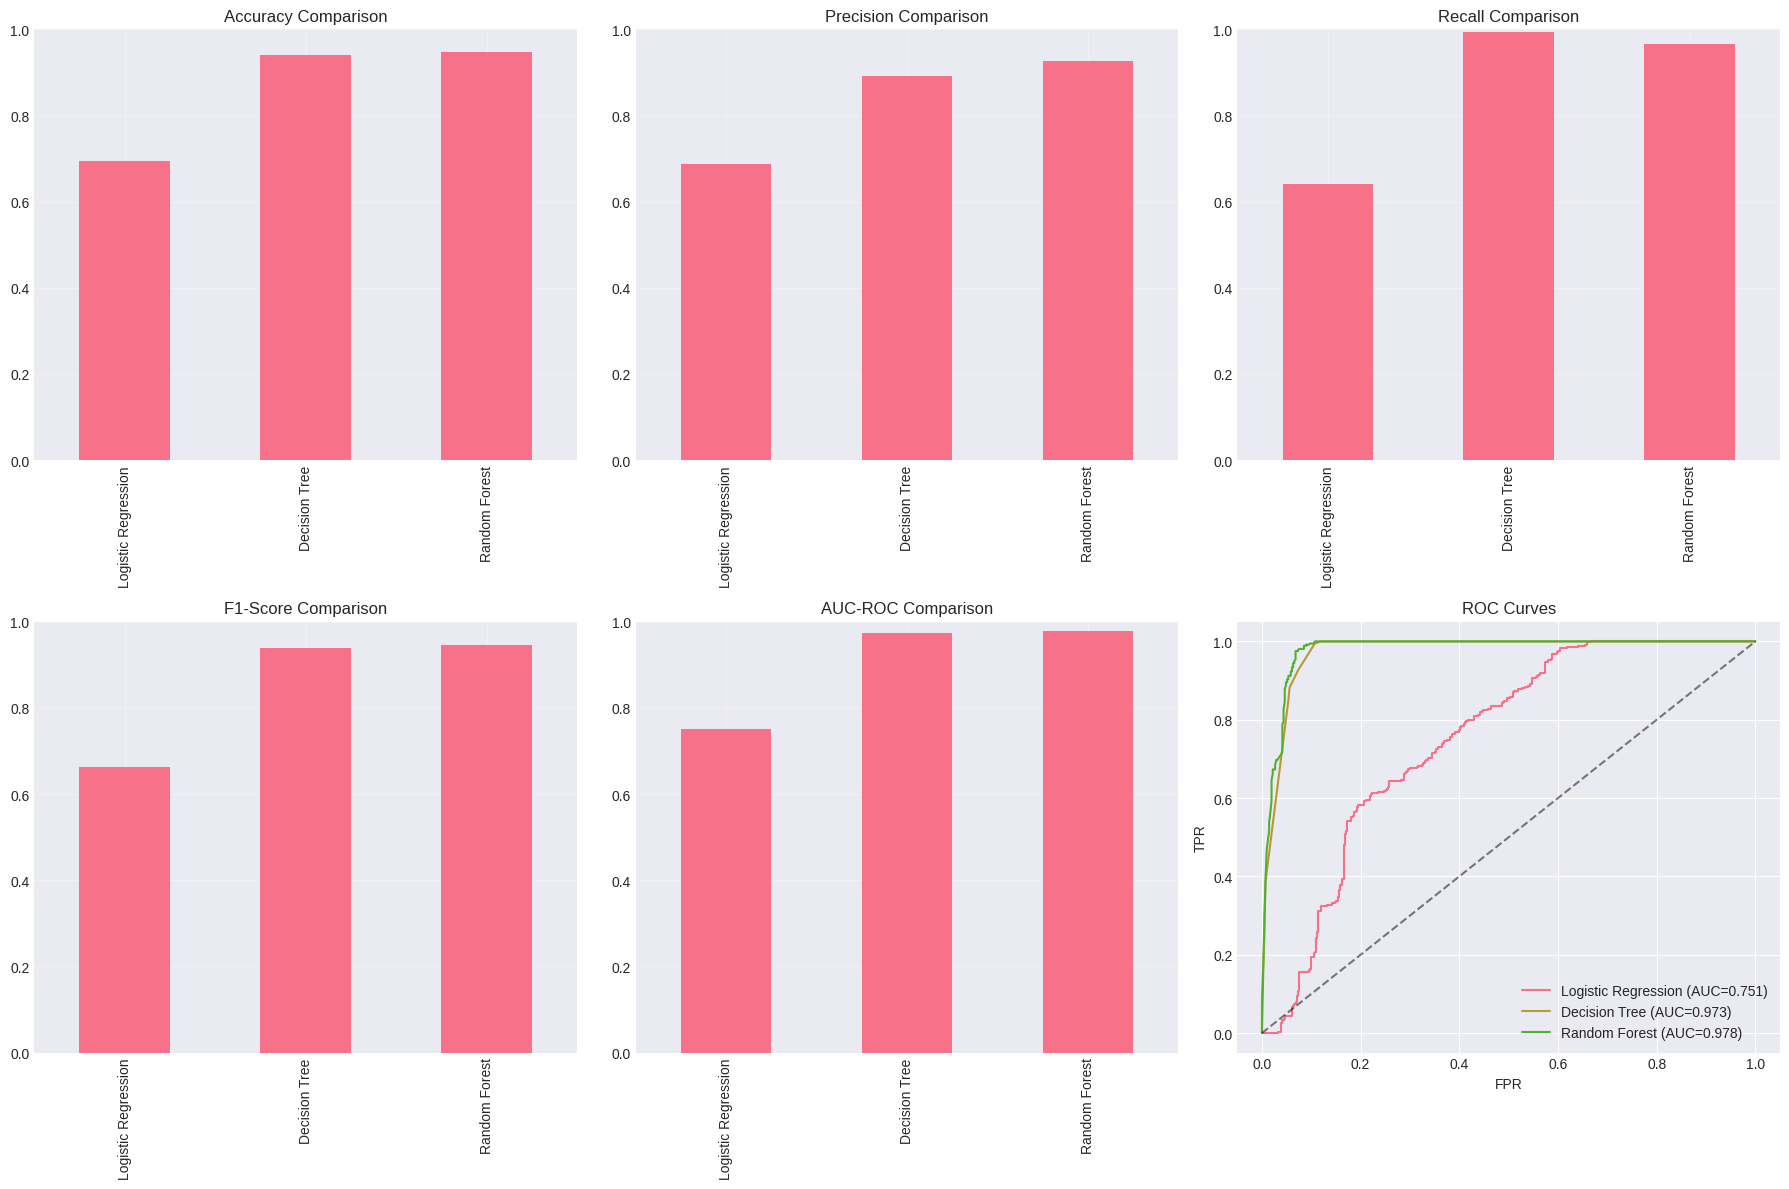

In [100]:
# Bar plots for metrics
fig, axes = plt.subplots(2,3, figsize=(18,12))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

for i, metric in enumerate(metrics):
    ax = axes[i//3, i%3]
    results_df[metric].plot(kind='bar', ax=ax)
    ax.set_title(metric + " Comparison")
    ax.set_ylim(0,1)
    ax.grid(alpha=0.3)

# ROC Curve
ax = axes[1,2]
for name, (fpr, tpr, auc) in roc_data.items():
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0,1],[0,1],'k--', alpha=0.5)
ax.set_title("ROC Curves")
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.legend()
plt.tight_layout()
plt.show()


#Feature Importance & Interpretation

In [101]:
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
feature_importance


,Feature,Importance
8,Offense Category,0.554285
7,PD Code Description,0.136505
2,Complaint Precinct Code,0.084968
6,Offense Description,0.058885
1,Month Number,0.058626
0,Complaint Year Number,0.044193
3,Patrol Borough Name,0.030828
5,Law Code Category Description,0.016888
4,County,0.014823


In [102]:
lr_model = models['Logistic Regression']
coeff_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)
coeff_df.head(5)


,Feature,Coefficient
8,Offense Category,0.811005
6,Offense Description,0.331588
4,County,0.248479
2,Complaint Precinct Code,0.079604
0,Complaint Year Number,0.032109
